# Example usage of ABCI-Categorical-GP

This notebook illustrates the example usage of ABCI with a categorical
distribution over graphs and a GP mechanism model. This setup scales up to systems with
four variables.

In [ ]:
# !conda uninstall pytorch
# !conda install pytorch==1.9.1 torchaudio=0.9.1 torchvision=0.10.1 cpuonly -c pytorch

In [14]:
# imports
%reload_ext autoreload
%autoreload 2


import matplotlib.pyplot as plt
import torch.distributions as dist
from matplotlib.ticker import MaxNLocator

from src.abci_categorical_gp import ABCICategoricalGP as ABCI
from src.environments.generic_environments import *
from src.models.gp_model import get_graph_key, gather_data


In [20]:
import torch
import networkx as nx
from src.environments.experiment import Experiment

# Example custom data with an inverse pattern between X1 and X2
num_batches = 1
batch_size = 50

# X1 is independent, we sample it from a normal distribution
X1_data = torch.linspace(-10, 10, steps=num_batches * batch_size).view(num_batches, batch_size, 1)

# X2 is inversely related to X1, e.g., X2 = -2 * X1 + some noise
noise = torch.randn(num_batches, batch_size, 1) * 0.2  # Adding small noise
X2_data = X1_data**2 + noise  # Inverse relationship between X1 and X2

# Combine into custom data for experiments
custom_data = {'X1': X1_data, 'X2': X2_data}

# Example interventions dictionary (no interventions in this case)
custom_interventions = {'X1': True, 'X2': False}

# Create an Experiment instance with custom data
experiment = Experiment(interventions=custom_interventions, data=custom_data)

# Create a list of Experiment instances
experiments = [experiment]

# Define a simple graph structure where X1 influences X2
graph_test = nx.DiGraph()
graph_test.add_edges_from([('X1', 'X2')])  # X1 influences X2

# # Call the gather_data function with custom experiments and graph
# inputs, targets = gather_data(experiments, 'X1', graph=graph, mode='joint')

# # Print the extracted inputs and targets to see if the inverse relationship is captured
# print("Inputs:", inputs)
# print("Targets:", targets)


Given shape dict is {}
given base shape for node X1 is 1
set node X1, with data of shape torch.Size([50, 1, 1])
node X2 expected shape (50, 1, 1), giving torch.Size([50, 1, 1])
starting synthetic data loop
set node X1 data to shape torch.Size([1, 1, 1])
node X2 expected shape (1, 1, 1), giving torch.Size([1, 1, 1])
set node X1 data to shape torch.Size([1, 1, 1])
node X2 expected shape (1, 1, 1), giving torch.Size([1, 1, 1])
set node X1 data to shape torch.Size([1, 1, 1])
node X2 expected shape (1, 1, 1), giving torch.Size([1, 1, 1])
set node X1 data to shape torch.Size([1, 1, 1])
node X2 expected shape (1, 1, 1), giving torch.Size([1, 1, 1])
set node X1 data to shape torch.Size([1, 1, 1])
node X2 expected shape (1, 1, 1), giving torch.Size([1, 1, 1])
set node X1 data to shape torch.Size([1, 1, 1])
node X2 expected shape (1, 1, 1), giving torch.Size([1, 1, 1])
set node X1 data to shape torch.Size([1, 1, 1])
node X2 expected shape (1, 1, 1), giving torch.Size([1, 1, 1])
set node X1 data 

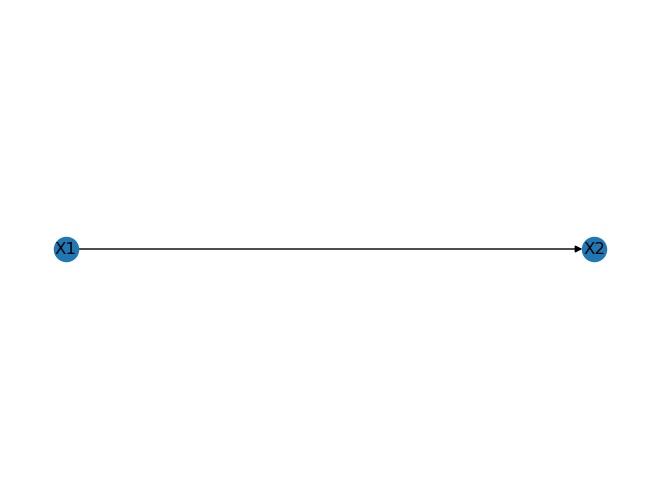

In [21]:
# specify the number of nodes and (optionally) a query of interventional variables
num_nodes = 2
# interventional_queries = None
interventional_queries = [InterventionalDistributionsQuery(['X2'], {'X1': dist.Uniform(3, 4.)}, sample_queries=experiments)]

# generate the ground truth environment
env = BiDiag(num_nodes,
             num_test_queries=10,
             interventional_queries=interventional_queries,
graph=graph_test)

# plot true graph
nx.draw(env.graph, nx.planar_layout(env.graph), labels=dict(zip(env.graph.nodes, env.graph.nodes)))


In [22]:
print(X1_data.shape)
print(X2_data.shape)

env.mechanisms['X2'].set_data(X1_data, X2_data.squeeze(-1))

torch.Size([1, 50, 1])
torch.Size([1, 50, 1])


In [5]:
import gpytorch

gp_model = env.mechanisms['X2'].gp  # The Gaussian Process for 'X1'
gp_model.train()

likelihood = gpytorch.likelihoods.GaussianLikelihood()
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, gp_model)
optimizer = torch.optim.Adam(gp_model.parameters(), lr=0.01)
num_epochs = 1000
for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = gp_model(X1_data)
    # print(output.shape)
    loss = -mll(output, X2_data.squeeze(-1)).mean()
    # print(loss.shape)
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item()}')
print('Training Process Completed')
# tester = noise = torch.randn(10)
# tester.dim()



Epoch 1/1000, Loss: 2.4850027561187744
Epoch 501/1000, Loss: 1.6562108993530273
Training Process Completed


Next, we can examine the ground truth mechanisms.

torch.Size([10, 10, 1])
output shape is currently f_dist.mean torch.Size([10, 10])


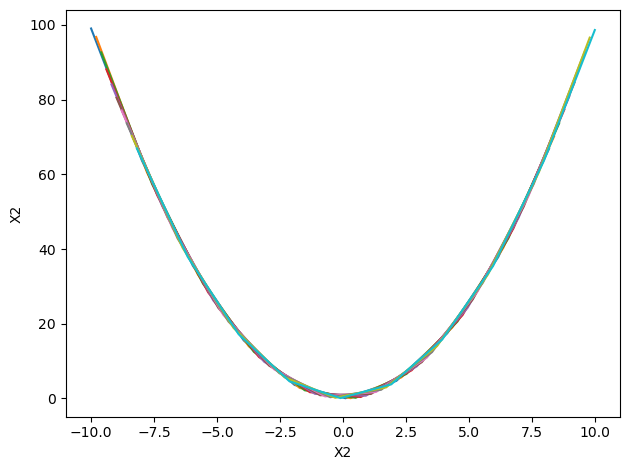

In [23]:
# plotting a univariate mechanism
node = 'X2'  # target node
num_points = 100
xrange = torch.linspace(-10., 10., num_points).view(10,10,1)#.unsqueeze(1)
# print(xrange.dim())
print(xrange.shape)
ytrue = env.mechanisms[node](xrange, prior_mode=False).detach()

plt.figure()
plt.plot(xrange.squeeze(-1), ytrue.squeeze(-1))
plt.xlabel('X2')
plt.ylabel(node)
plt.tight_layout()

torch.Size([10, 10, 1])
output shape is currently f_dist.mean torch.Size([10, 10])


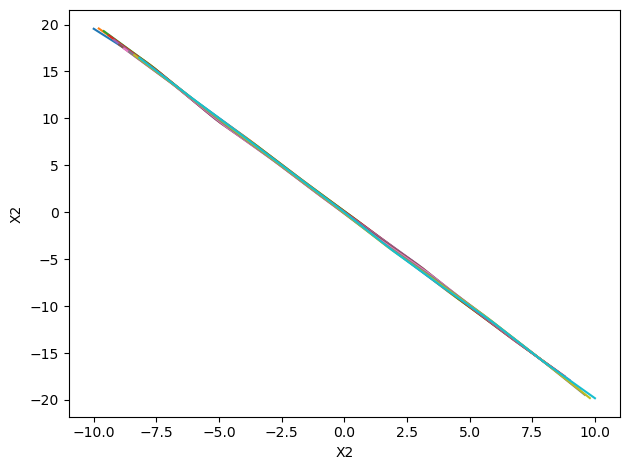

In [6]:
# plotting a univariate mechanism
node = 'X2'  # target node
num_points = 100
xrange = torch.linspace(-10., 10., num_points).view(10,10,1)#.unsqueeze(1)
# print(xrange.dim())
print(xrange.shape)
ytrue = env.mechanisms[node](xrange, prior_mode=False).detach()

plt.figure()
plt.plot(xrange.squeeze(-1), ytrue.squeeze(-1))
plt.xlabel('X2')
plt.ylabel(node)
plt.tight_layout()

In [7]:
# # plotting a bivariate mechanism
# node = 'X2'  # target node
# num_points = 100
# xrange = torch.linspace(-7., 7., num_points)
# yrange = torch.linspace(-7., 7., num_points)
# xgrid, ygrid = torch.meshgrid(xrange, yrange)
# ztrue = env.mechanisms[node](torch.stack((xgrid, ygrid), dim=2).view(-1, 2))
# zmin = ztrue.min().item()
# zmax = ztrue.max().item()
# print(f'Function values for {node} in range [{zmin, zmax}].')
# ztrue = ztrue.detach().view(num_points, num_points).numpy()

# levels = torch.linspace(zmin, zmax, 30).numpy()
# fig, ax = plt.subplots()
# cp1 = ax.contourf(xgrid, ygrid, ztrue, cmap=plt.get_cmap('jet'), levels=levels, vmin=zmin, vmax=zmax,
#                   antialiased=False)
# ax.set_xlabel('X0')
# ax.set_ylabel('X1')
# _ = fig.colorbar(cp1)

# # _, ax = plt.subplots(subplot_kw={"projection": "3d"})
# # surf = ax.plot_surface(xgrid, ygrid, ztrue, cmap=plt.get_cmap('jet'), linewidth=0, antialiased=False)
# # ax.set_xlabel('X0')
# # ax.set_ylabel('X1')
# # ax.set_zlabel(node)

Here, we create an ABCI instance with the desired experimental design policy.

In [7]:
policy = 'observational'
abci = ABCI(env, policy)

We can now run a number of ABCI loops.

In [8]:
num_experiments = 3
batch_size = 3

abci.run(num_experiments, batch_size, num_initial_obs_samples=3)

trying to execute mll
Targets shape: torch.Size([50, 1])
Output shape: torch.Size([50])
LLS shape after log_prob: torch.Size([50])
excepion not occuring
trying to execute mll
f_dist shape: torch.Size([50, 1])
targets shape: torch.Size([50, 1])
mlls shape after log_prob: torch.Size([50])
excepion not occuring
trying to execute mll
f_dist shape: torch.Size([50, 1])
targets shape: torch.Size([50, 1])
mlls shape after log_prob: torch.Size([50])
excepion not occuring
trying to execute mll
Targets shape: torch.Size([50, 1])
Output shape: torch.Size([50])
LLS shape after log_prob: torch.Size([50])
excepion not occuring
Starting experiment cycle 1/3...
Design and perform experiment...
Updating 4 GP's hyperparams with first 1 experiments.
Targets shape: torch.Size([3])
Output shape: torch.Size([])
LLS shape after log_prob: torch.Size([])
Targets shape: torch.Size([3])
Output shape: torch.Size([])
LLS shape after log_prob: torch.Size([])
f_dist shape: <bound method TorchDistributionMixin.shape o

Here, we plot the training stats and results.

In [ ]:
print(f'Number of observational batches: {len([e for e in abci.experiments if e.interventions == {}])}')
for node in env.node_labels:
    print(
        f'Number of interventional batches on {node}: {len([e for e in abci.experiments if node in e.interventions])}')

# plot expected SHD over experiments
ax = plt.figure().gca()
plt.plot(abci.eshd_list)
plt.xlabel('Number of Experiments')
plt.ylabel('Expected SHD')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# plot true graph NLL over experiments
ax = plt.figure().gca()
plt.plot(-torch.tensor(abci.graph_ll_list))
plt.xlabel('Number of Experiments')
plt.ylabel('True Graph NLL')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# plot graph posterior
graphs = abci.graph_posterior.sort_by_prob()[0:10]
probs = [abci.graph_posterior.log_prob(g).exp().detach() for g in graphs]
graph_keys = [get_graph_key(g) for g in graphs]

plt.figure()
plt.xticks(rotation=90)
plt.bar(graph_keys, probs)
plt.ylabel(r'Graph Posterior, $p(G|D)$')

# plot graph posterior entropy over experiments
ax = plt.figure().gca()
plt.plot(abci.graph_entropy_list, label='entropy estimate')
plt.xlabel('Number of Experiments')
plt.ylabel('Entropy of Graph Posterior')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()

# plot Query KLD over experiments
ax = plt.figure().gca()
plt.plot(abci.query_kld_list)
plt.xlabel('Number of Experiments')
plt.ylabel('Query KLD')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()

Finally, we can have a look at the learned vs. true mechanisms.

In [ ]:
# plot X_i -> X_j true vs. predicted
i = 1
j = 2
xdata, ydata = gather_data(abci.experiments, f'X{j}', parents=[f'X{i}'])
xrange = torch.linspace(xdata.min(), xdata.max(), 100).unsqueeze(1)
ytrue = env.mechanisms[f'X{j}'](xrange).detach()
mech = abci.mechanism_model.get_mechanism(f'X{j}', parents=[f'X{i}'])
mech.set_data(xdata, ydata)
ypred = mech(xrange).detach()

plt.figure()
plt.plot(xdata, ydata, 'rx', label='Experimental Data')
plt.plot(xrange, ytrue, label=f'X{i}->X{j} true')
plt.plot(xrange, ypred, label=f'X{i}->X{j} prediction')
plt.xlabel(f'X{i}')
plt.ylabel(f'X{j}')
plt.legend()
plt.tight_layout()

In [ ]:
# plot bivariate mechanisms
node = 'X2'
num_points = 100
xrange = torch.linspace(-10., 10., num_points)
yrange = torch.linspace(-10., 10., num_points)
xgrid, ygrid = torch.meshgrid(xrange, yrange)
inputs = torch.stack((xgrid, ygrid), dim=2).view(-1, 2)
ztrue = env.mechanisms[node](inputs).detach().view(num_points, num_points).numpy()

parents = ['X1']
mech = abci.mechanism_model.get_mechanism(node, parents=parents)
zpred = mech(inputs)
zpred = zpred.detach().view(num_points, num_points).numpy()

zmin = ztrue.min().item()
zmax = ztrue.max().item()
print(f'Function values for {node} in range [{zmin, zmax}].')

levels = torch.linspace(zmin, zmax, 30).numpy()
fig, axes = plt.subplots(1, 2)
cp1 = axes[0].contourf(xgrid, ygrid, ztrue, cmap=plt.get_cmap('jet'), levels=levels, vmin=zmin, vmax=zmax)
cp2 = axes[1].contourf(xgrid, ygrid, zpred, cmap=plt.get_cmap('jet'), levels=levels, vmin=zmin, vmax=zmax)

inputs, targets = gather_data(abci.experiments, node, parents=parents)
axes[0].plot(inputs[:, 0], inputs[:, 1], 'kx')

axes[0].set_xlabel(parents[0])
axes[1].set_xlabel(parents[0])
axes[0].set_ylabel(parents[1])
_ = fig.colorbar(cp2)